# 02 — Interventional dependency mapping

## What this notebook is for

A water distribution network is a rare object of study: we can apply the **do-operator**
directly. Perturb one node's demand, solve, and read the effect on every other node. The
result is the *true* dependence structure at that operating point, not an estimate of it.

That matters because every observational method we will later apply — Granger causality,
transfer entropy — recovers dependence from passive data, which is all a real utility ever
has. Having the interventional answer turns "is our causal estimator right?" from an
argument into a measurement. Notebook 03 does that scoring; this notebook builds the
ground truth and establishes that it is trustworthy.

## Definitions

| symbol | meaning |
|---|---|
| $S_{ij} = \partial p_i / \partial d_j$ | **instantaneous influence**: pressure change at $i$ per unit demand added at $j$, in m per m³/s |
| $\delta$ | perturbation step, in m³/s, chosen by calibration |
| *reach* of $j$ | number of nodes whose response to $j$ exceeds the noise floor |
| *coupling ratio* | off-diagonal share of the district-aggregated influence mass; 0 = separable clients, 1 = district labels hydraulically meaningless |
| $\text{lag}_{ij}$ | hours at which $i$'s response to a shape change at $j$ peaks |

## The one result that shapes everything downstream

EPANET's extended-period simulation is **quasi-steady**: every timestep solves an
independent steady-state problem. For a pipes-only network the demand-to-pressure Jacobian
is the inverse of a symmetric matrix, so $S$ **must** be symmetric — hydraulic reciprocity,
the analogue of Maxwell–Betti.

Two consequences:

1. Symmetry is a **hard, falsifiable test** of the whole pipeline. If a valveless network
   comes back asymmetric, the method is broken, not the network.
2. **Instantaneous hydraulic coupling carries no direction.** Any genuine direction in this
   system must come from tank mass or control switching. A network with neither cannot
   produce lagged causality at all, however confident a time-series estimator sounds.

Both are tested below rather than asserted.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import wntr

sys.path.insert(0, str(Path.cwd()))
import wdn_dependency as dep

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 200)
warnings.simplefilter("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})


def find_network_dir(candidates=("../../data/00_networks", "nets", "networks", ".")):
    """Locate the corpus without hardcoding a path, so the notebook is portable."""
    for c in candidates:
        p = Path(c)
        if p.is_dir() and any(p.glob("*.inp")):
            return p
    raise FileNotFoundError(f"no .inp files found under any of {candidates}")


NETWORK_DIR = find_network_dir()
OUT_DIR = Path("data/08_reporting/dependency")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FILES = sorted(NETWORK_DIR.glob("*.inp"))
print(f"{len(FILES)} networks in {NETWORK_DIR}")

21 networks in ..\..\data\00_networks


## 1. Corpus characterisation and network selection

Selection needs two axes, because they control different things:

- **Topology** (branched → sparse-grid → dense-grid) sets how a perturbation spreads. In a
  tree, every junction has exactly one supply path, so dependence is fixed by topology and
  would make a causal estimator look good for a reason that will not generalise. In a dense
  grid, parallel paths absorb the perturbation and pairwise coupling weakens.
- **Hydraulic components** (tanks, pumps, valves) set whether *direction* and *lag* can
  exist at all, and introduce the pathologies (PRV regulation, POWER-pump deadheading) that
  break a naive analysis.

Meshedness $\alpha = \text{loops}/(2n-5)$ is measured here and cross-checked against the
readme's published classification, on the principle that the readme is a claim until tested.

In [2]:
def topology_census(path):
    """Measured structure and component counts for one network."""
    wn = wntr.network.WaterNetworkModel(str(path))
    g = wn.to_graph().to_undirected()
    s = nx.Graph()
    s.add_nodes_from(g.nodes())
    s.add_edges_from((u, v) for u, v, _ in g.edges(keys=True))
    n, e = s.number_of_nodes(), s.number_of_edges()
    loops = e - n + nx.number_connected_components(s)
    cons = dep.consumer_nodes(wn)
    q = sum(dep.base_demand_of(wn, j) for j in cons) * dep.LPS_PER_M3S
    mult = float(wn.options.hydraulic.demand_multiplier or 1.0)
    deg = np.array([d for _, d in s.degree()])
    return {
        "network": path.stem, "n_nodes": n, "n_links": e, "loops": loops,
        "meshedness": loops / (2 * n - 5) if n > 2 else np.nan,
        "dead_end_frac": float((deg == 1).mean()),
        "n_consumers": len(cons), "demand_lps": q * mult,
        "tanks": len(wn.tank_name_list), "pumps": len(wn.pump_name_list),
        "valves": len(wn.valve_name_list), "reservoirs": len(wn.reservoir_name_list),
        "controls": len(wn.control_name_list),
        "can_carry_lag": bool(wn.tank_name_list) or len(wn.control_name_list) > 0,
    }


census = pd.DataFrame([topology_census(f) for f in FILES]).set_index("network")
census.sort_values("meshedness").round(4)

,n_nodes,n_links,loops,meshedness,dead_end_frac,n_consumers,demand_lps,tanks,pumps,valves,reservoirs,controls,can_carry_lag
network,,,,,,,,,,,,,
Balerma,447,454,8,0.0090,0.2707,442,1103.8950,0,0,0,4,0,False
ky12,2355,2452,98,0.0208,0.1834,2246,60.0442,7,15,22,1,6,True
ky17,6261,6578,318,0.0254,0.1779,2622,221.7331,3,5,0,1,0,True
ky15,669,703,35,0.0263,0.2780,565,64.7199,8,13,28,2,16,True
ky9,1261,1332,72,0.0286,0.3339,1030,58.7452,15,17,56,4,10,True
ky11,831,880,50,0.0302,0.3418,694,76.5436,28,21,15,1,12,True
C_Town,396,444,49,0.0623,0.1970,0,0.0000,7,11,4,1,20,True
D_Town,407,459,53,0.0655,0.1916,348,422.2676,7,11,5,1,24,True
ky10,935,1059,125,0.0670,0.2749,871,94.7224,13,13,5,2,6,True


In [3]:
def parse_readme_classes(network_dir):
    """Pull the published Hwang & Lansey / Hoagland labels, if the readme is present."""
    import re
    hits = list(network_dir.glob("*readme*"))
    if not hits:
        return pd.DataFrame()
    text = hits[0].read_text(errors="replace")
    rows = []
    for part in re.split(r"\n(?=\d{2}\s+\S)", text)[1:]:
        head, _, body = part.partition("\n")
        m = re.match(r"\d{2}\s+(.+?)\s*$", head)
        if not m:
            continue
        name = m.group(1).strip().lower()
        stem = {"balerma": "Balerma", "c-town": "C_Town", "d-town": "D_Town"}.get(name)
        if stem is None:
            g = re.match(r"ky\s*(\d+)", name)
            stem = f"ky{g.group(1)}" if g else (
                "Graeme" if "graeme" in name or "zhi" in name else None)
        blob = " ".join(body.split())
        hw = re.search(r"classified as ([\w\s-]+?) by Hw", blob)
        ho = re.search(r"and ([\w-]+) by Hoagland", blob)
        rows.append({"network": stem, "readme_name": name,
                     "class_hwang": hw.group(1).strip() if hw else None,
                     "class_hoagland": ho.group(1).strip() if ho else None})
    return pd.DataFrame(rows).dropna(subset=["network"]).set_index("network")


classes = parse_readme_classes(NETWORK_DIR)
profile = census.join(classes, how="left") if len(classes) else census.copy()
profile.to_csv(OUT_DIR / "corpus_profile.csv")

# Sanity check: does measured meshedness order agree with the published labels?
if "class_hoagland" in profile:
    display(profile.groupby("class_hoagland").meshedness
            .agg(["count", "min", "median", "max"]).round(4))
    print("If branched < gridded/looped in median meshedness, the published "
          "classification is consistent with the files and usable as a design axis.")

,count,min,median,max
class_hoagland,,,,
branched,5,0.0090,0.0263,0.0302
gridded,7,0.0254,0.1212,0.2110
looped,9,0.0623,0.0899,0.1046


If branched < gridded/looped in median meshedness, the published classification is consistent with the files and usable as a design axis.


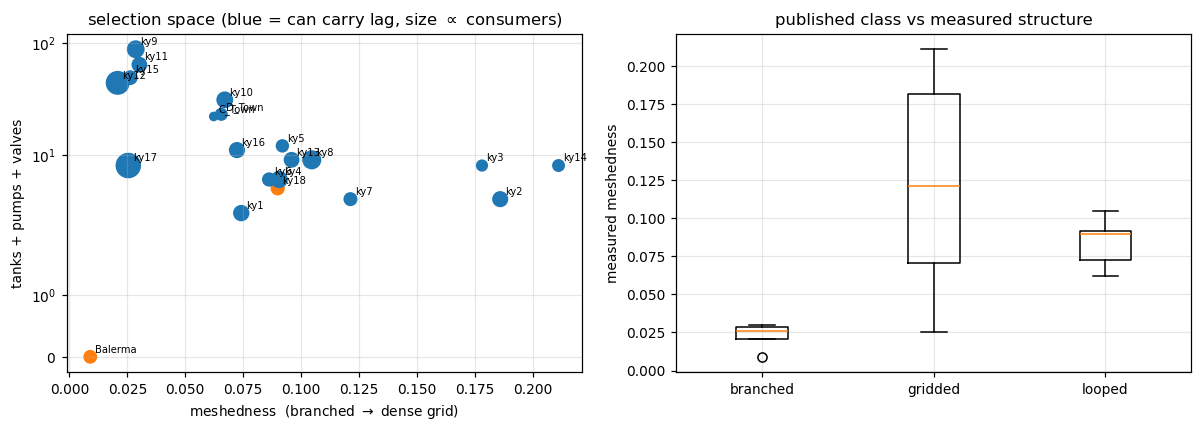

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
hyd = profile.tanks + profile.pumps + profile.valves
sc = ax[0].scatter(profile.meshedness, hyd, s=28 + profile.n_consumers / 12,
                   c=profile.can_carry_lag.map({True: "tab:blue", False: "tab:orange"}))
for n, r in profile.iterrows():
    ax[0].annotate(n, (r.meshedness, r.tanks + r.pumps + r.valves),
                   fontsize=6.5, xytext=(3, 3), textcoords="offset points")
ax[0].set_xlabel("meshedness  (branched $\\to$ dense grid)")
ax[0].set_ylabel("tanks + pumps + valves")
ax[0].set_yscale("symlog")
ax[0].set_title("selection space (blue = can carry lag, size $\\propto$ consumers)")
ax[0].grid(alpha=0.3)

if "class_hoagland" in profile:
    order = profile.dropna(subset=["class_hoagland"]).groupby("class_hoagland").meshedness
    labels = list(order.groups)
    ax[1].boxplot([order.get_group(k).to_numpy() for k in labels], tick_labels=labels)
    ax[1].set_ylabel("measured meshedness")
    ax[1].set_title("published class vs measured structure")
    ax[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [5]:
# Selection rule, applied to the measured profile rather than chosen by hand:
# span the topology axis, keep hydraulic complexity low, and require demand.
# Two of the picks must be able to carry lag (tanks/controls) and one must not,
# so the lag result has a negative control.
def select_networks(profile, n_per_band=3, max_components=20):
    p = profile[(profile.n_consumers > 0)].copy()
    p["hydraulic_complexity"] = p.tanks + p.pumps + p.valves
    p["band"] = pd.cut(p.meshedness, [-np.inf, 0.04, 0.08, 0.15, np.inf],
                       labels=["branched", "sparse_grid", "grid", "dense_grid"])
    picks = []
    for band, g in p.groupby("band", observed=True):
        g = g[g.hydraulic_complexity <= max_components]
        if g.empty:
            g = p[p.band == band].nsmallest(n_per_band, "hydraulic_complexity")
        picks.append(g.nsmallest(n_per_band, "hydraulic_complexity"))
    out = pd.concat(picks)
    return out[["band", "meshedness", "n_consumers", "tanks", "pumps",
                "valves", "controls", "can_carry_lag", "hydraulic_complexity"]]


SELECTED = select_networks(profile)
display(SELECTED.round(4))
print("lag-capable in selection:", int(SELECTED.can_carry_lag.sum()),
      "of", len(SELECTED), "— a negative control is present"
      if (~SELECTED.can_carry_lag).any() else "— NO negative control, add a tankless network")

,band,meshedness,n_consumers,tanks,pumps,valves,controls,can_carry_lag,hydraulic_complexity
network,,,,,,,,,
Balerma,branched,0.0090,442,0,0,0,0,False,0
ky17,branched,0.0254,2622,3,5,0,0,True,8
ky1,sparse_grid,0.0741,797,2,1,0,0,True,3
ky16,sparse_grid,0.0723,768,4,7,0,6,True,11
ky7,grid,0.1212,463,3,1,0,2,True,4
ky18,grid,0.0899,495,0,3,2,0,False,5
ky4,grid,0.0905,934,4,2,0,2,True,6
ky2,dense_grid,0.1858,757,3,1,0,2,True,4
ky14,dense_grid,0.2110,331,3,5,0,3,True,8


lag-capable in selection: 8 of 10 — a negative control is present


## 2. Perturbation step calibration

A finite-difference derivative sits between two errors that move in opposite directions.

**Too small.** EPANET writes its binary output as 4-byte floats, so every pressure carries
a relative quantisation error of ~1.2e-7. At 50 m that is ~6e-6 m, and a difference of two
such values cannot resolve anything finer. This is a hard limit: setting EPANET's
`accuracy` from 1e-3 to 1e-8 changes nothing, while the float64 pure-Python solver
reproduces the same first-order term with a ~5× smaller second-order term.

**Too large.** Second-order curvature stops being negligible and the difference no longer
approximates a derivative.

Central differencing measures both at once, and their ratio
$r(\delta) = \max|\text{2nd order}| / \max|\text{1st order}|$ is U-shaped. The step is chosen
at the minimum. **This must be measured, not assumed**: the intuition "smaller is more
linear" is exactly backwards here, because noise does not shrink with $\delta$ while the
signal does.

Balerma   delta=   0.0500 L/s (fraction 0.02 of mean demand)  ratio=1.17e-03  
ky17      delta=   0.1691 L/s (fraction 2 of mean demand)  ratio=1.06e-01  chosen step sits at the edge of the candidate grid -- widen calibration_fractions, the optimum may lie outside it
ky1       delta=   0.0544 L/s (fraction 0.5 of mean demand)  ratio=4.18e-02  
ky16      delta=   0.0427 L/s (fraction 0.5 of mean demand)  ratio=2.28e-02  
ky7       delta=   0.2894 L/s (fraction 2 of mean demand)  ratio=4.22e-02  chosen step sits at the edge of the candidate grid -- widen calibration_fractions, the optimum may lie outside it
ky18      delta=   0.1220 L/s (fraction 1 of mean demand)  ratio=1.65e-02  
ky4       delta=   0.0703 L/s (fraction 1 of mean demand)  ratio=2.48e-02  
ky2       delta=   0.0302 L/s (fraction 0.25 of mean demand)  ratio=3.15e-02  
ky14      delta=   0.2759 L/s (fraction 2 of mean demand)  ratio=1.57e-02  chosen step sits at the edge of the candidate grid -- widen calibration_fractions

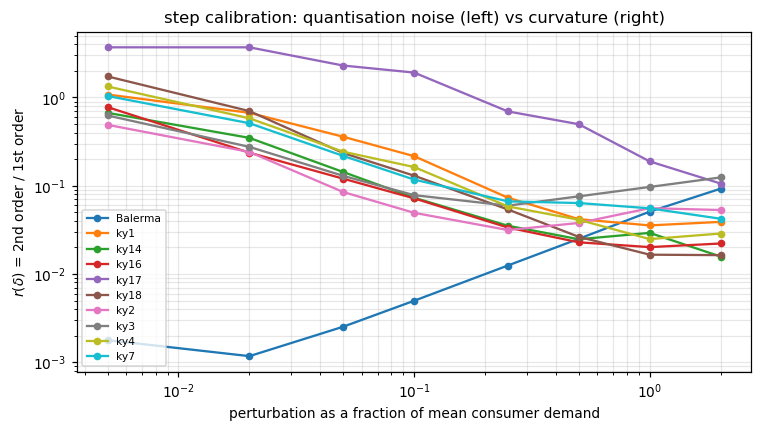

A minimum in the interior is a well-conditioned step. A minimum at the right edge means the network's pressure response is weak relative to float32 quantisation — typical of dense grids, where parallel paths absorb a single node's perturbation.


In [6]:
CFG = dep.DependencyConfig(
    perturbation_mode="absolute",   # comparable Jacobian; lets reciprocity be tested
    central_difference=True,        # yields the noise floor as a by-product
    calibrate=True,
    max_probe_nodes=60,             # raise for a full map; cost is linear in probes
    probe_strategy="stratified",
    operating_lambdas=(0.5, 1.0, 2.0),
    record_flow=False,
    seed=11,
)

cal_rows = []
for name in SELECTED.index:
    wn = wntr.network.WaterNetworkModel(str(NETWORK_DIR / f"{name}.inp"))
    c = dep.calibrate_delta(wn, CFG)
    cur = c["curve"].assign(network=name)
    cal_rows.append(cur)
    print(f"{name:9s} delta={c['delta_m3s'] * 1000:9.4f} L/s "
          f"(fraction {c['fraction']:g} of mean demand)  "
          f"ratio={c['chosen_ratio']:.2e}  {c.get('warning', '')}")
calibration = pd.concat(cal_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 4))
for name, g in calibration.groupby("network"):
    g = g.sort_values("fraction")
    ax.plot(g.fraction, g.mean_ratio, marker="o", ms=4, label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("perturbation as a fraction of mean consumer demand")
ax.set_ylabel("$r(\\delta)$ = 2nd order / 1st order")
ax.set_title("step calibration: quantisation noise (left) vs curvature (right)")
ax.legend(fontsize=7)
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()
print("A minimum in the interior is a well-conditioned step. A minimum at the right edge "
      "means the network's pressure response is weak relative to float32 quantisation — "
      "typical of dense grids, where parallel paths absorb a single node's perturbation.")

## 3. Sanity checks on the instantaneous map

Four independent tests, each able to fail:

1. **Reciprocity.** $S$ symmetric for pipes-only networks. Expect ~1e-4 relative asymmetry.
   Larger values are physical (PRV, check valve, pump) and localise directional elements.
2. **Sign.** Adding demand must not raise pressure. Violations mean an active regulator
   changed regime, and are located rather than swept up.
3. **Decay with hydraulic distance.** Influence must fall with resistance distance
   ($\sum L/D^5$ along the path). No decay means the map is wrong.
4. **Structural zeros.** An exact zero is hydraulic separation (a distinct pressure zone),
   categorically different from weak coupling, and reported apart from it.

In [7]:
MAPS = {}
for name in SELECTED.index:
    wn = wntr.network.WaterNetworkModel(str(NETWORK_DIR / f"{name}.inp"))
    m = dep.instantaneous_map(wn, CFG, lam=1.0)
    MAPS[name] = {"wn": wn, "map": m,
                  "symmetry": dep.symmetry_diagnostics(m, wn),
                  "signs": dep.sign_diagnostics(m),
                  "zones": dep.zone_structure(m, CFG),
                  "decay": dep.influence_vs_distance(m, wn)}
    print(f"{name:9s} {len(m['probes']):4d} probes in {m['seconds']:6.1f}s")

checks = pd.DataFrame([{
    "network": n,
    "rel_asymmetry": d["symmetry"].get("relative_asymmetry", np.nan),
    "frobenius_asymmetry": d["symmetry"].get("frobenius_asymmetry", np.nan),
    "directional_elements": d["symmetry"].get("n_directional_elements", np.nan),
    "frac_positive_S": d["signs"]["frac_positive"],
    "frac_exact_zero": d["zones"]["frac_exact_zero"],
    "median_reach": float(d["zones"]["reach_per_probe"].median()),
    "decay_loglog_corr": d["decay"].attrs.get("log_log_corr", np.nan),
    "quantisation_floor_m": d["map"]["quantization_floor_m"],
} for n, d in MAPS.items()]).set_index("network")

checks["reciprocity_verdict"] = np.where(
    checks.rel_asymmetry < 0.01, "PASS (numerical only)",
    np.where(checks.directional_elements > 0,
             "asymmetric — directional elements present",
             "FAIL — investigate, no directional element explains this"))
checks["decay_verdict"] = np.where(checks.decay_loglog_corr < 0,
                                   "PASS (influence falls with distance)",
                                   "FAIL (no decay)")
checks.to_csv(OUT_DIR / "sanity_checks.csv")
checks.round(5)

Balerma     60 probes in    5.6s
ky17        60 probes in   82.2s
ky1         60 probes in    9.9s
ky16        60 probes in   13.0s
ky7         60 probes in    6.3s
ky18        60 probes in    9.2s
ky4         60 probes in   18.4s
ky2         60 probes in   10.6s
ky14        60 probes in    5.2s
ky3         60 probes in    4.2s


,rel_asymmetry,frobenius_asymmetry,directional_elements,frac_positive_S,frac_exact_zero,median_reach,decay_loglog_corr,quantisation_floor_m,reciprocity_verdict,decay_verdict
network,,,,,,,,,,
Balerma,0.00002,0.00010,0,0.00000,0.43244,311.0,-0.36165,0.00002,PASS (numerical only),PASS (influence falls with distance)
ky17,0.00067,0.00242,0,0.02179,0.01106,228.5,-0.02214,0.00004,PASS (numerical only),PASS (influence falls with distance)
ky1,0.00001,0.00024,0,0.00000,0.06544,711.0,-0.03490,0.00004,PASS (numerical only),PASS (influence falls with distance)
ky16,0.00040,0.00418,0,0.00000,0.09476,230.5,-0.07559,0.00010,PASS (numerical only),PASS (influence falls with distance)
ky7,0.00011,0.00090,0,0.00000,0.00900,476.0,-0.15264,0.00003,PASS (numerical only),PASS (influence falls with distance)
ky18,0.00034,0.00253,4,0.00000,0.01246,397.5,-0.07958,0.00002,PASS (numerical only),PASS (influence falls with distance)
ky4,0.00033,0.00313,0,0.00000,0.15546,524.5,-0.14819,0.00003,PASS (numerical only),PASS (influence falls with distance)
ky2,0.00072,0.00711,0,0.00000,0.00613,807.0,-0.01927,0.00001,PASS (numerical only),PASS (influence falls with distance)
ky14,0.00012,0.00109,5,0.00000,0.03047,363.5,-0.16949,0.00003,PASS (numerical only),PASS (influence falls with distance)


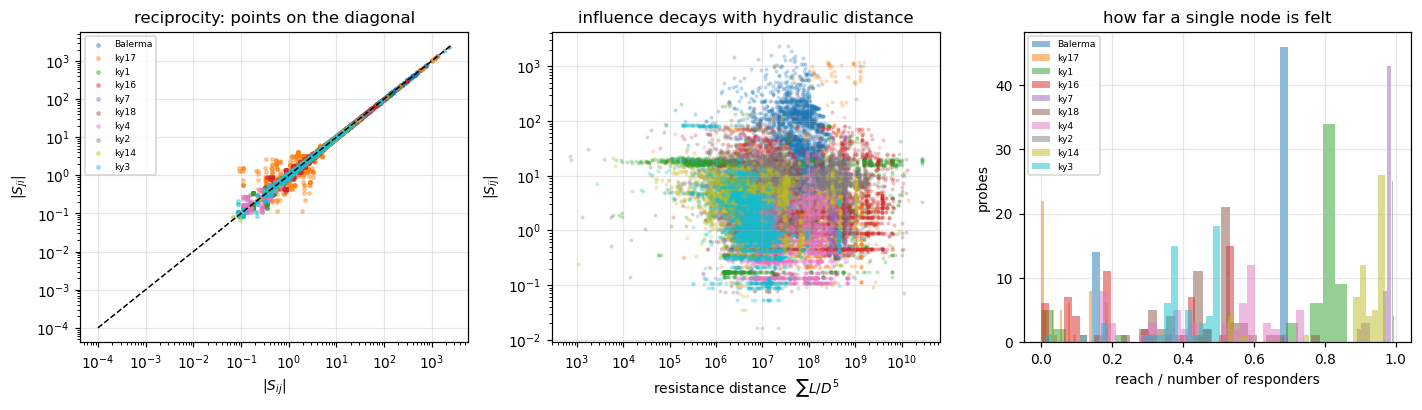

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

# reciprocity scatter, pooled over the selection
for name, d in MAPS.items():
    S = d["map"]["S"]
    common = [n for n in S.columns if n in S.index]
    if len(common) < 3:
        continue
    M = S.loc[common, common].to_numpy()
    iu = np.triu_indices(len(common), k=1)
    ax[0].scatter(np.abs(M[iu]), np.abs(M.T[iu]), s=5, alpha=0.35, label=name)
lim = [1e-4, max(1e-3, ax[0].get_xlim()[1])]
ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("$|S_{ij}|$")
ax[0].set_ylabel("$|S_{ji}|$")
ax[0].set_title("reciprocity: points on the diagonal")
ax[0].legend(fontsize=6)

# decay
for name, d in MAPS.items():
    df = d["decay"]
    if df.empty:
        continue
    s = df.sample(min(3000, len(df)), random_state=0)
    ax[1].scatter(s.resistance_distance, s.influence, s=3, alpha=0.2, label=name)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("resistance distance  $\\sum L/D^5$")
ax[1].set_ylabel("$|S_{ij}|$")
ax[1].set_title("influence decays with hydraulic distance")

# reach distribution
for name, d in MAPS.items():
    r = d["zones"]["reach_per_probe"]
    n_resp = d["map"]["S"].shape[0]
    ax[2].hist(r / n_resp, bins=25, alpha=0.5, label=name)
ax[2].set_xlabel("reach / number of responders")
ax[2].set_ylabel("probes")
ax[2].set_title("how far a single node is felt")
ax[2].legend(fontsize=6)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Single-network deep dive

The influence matrix reordered by discovered district shows whether hydraulic coupling is
block-structured. Strong blocks with weak off-diagonal mass mean the network genuinely
decomposes into near-independent subsystems, which is precisely the situation a federated
formulation assumes.

In [9]:
FOCUS = SELECTED.index[len(SELECTED) // 2]
N_DISTRICTS = 5

d = MAPS[FOCUS]
S = d["map"]["S"]
W = dep.symmetrize(S)
part = dep.discover_districts(S, N_DISTRICTS, seed=CFG.seed)
coup = dep.district_coupling(S, part)
rank = dep.influence_ranking(S)

print(f"{FOCUS}: {len(W)} nodes both probed and observed")
print("district sizes:", coup["sizes"].to_dict())
print(f"coupling ratio = {coup['coupling_ratio']:.4f}"
      "   (0 = separable clients, 1 = labels hydraulically meaningless)")
display(coup["coupling_matrix"].round(3))
display(rank.head(8).round(6))

ky18: 60 nodes both probed and observed
district sizes: {0: 8, 1: 16, 2: 10, 3: 15, 4: 11}
coupling ratio = 0.3567   (0 = separable clients, 1 = labels hydraulically meaningless)


,0,1,2,3,4
0,31.504,1.381,6.351,0.822,4.472
1,1.381,6.518,1.663,6.097,1.164
2,6.351,1.663,11.075,1.693,3.457
3,0.822,6.097,1.693,16.213,1.398
4,4.472,1.164,3.457,1.398,37.502


,total_influence,walk_influence
node,,
J-32,665.154480,0.028320
J-696,664.482117,0.028290
J-445,659.103577,0.028090
J-728,654.686584,0.027927
J-184,624.971436,0.026831
J-69,615.949829,0.026494
J-46,504.676422,0.023397
J-112,500.783173,0.023205


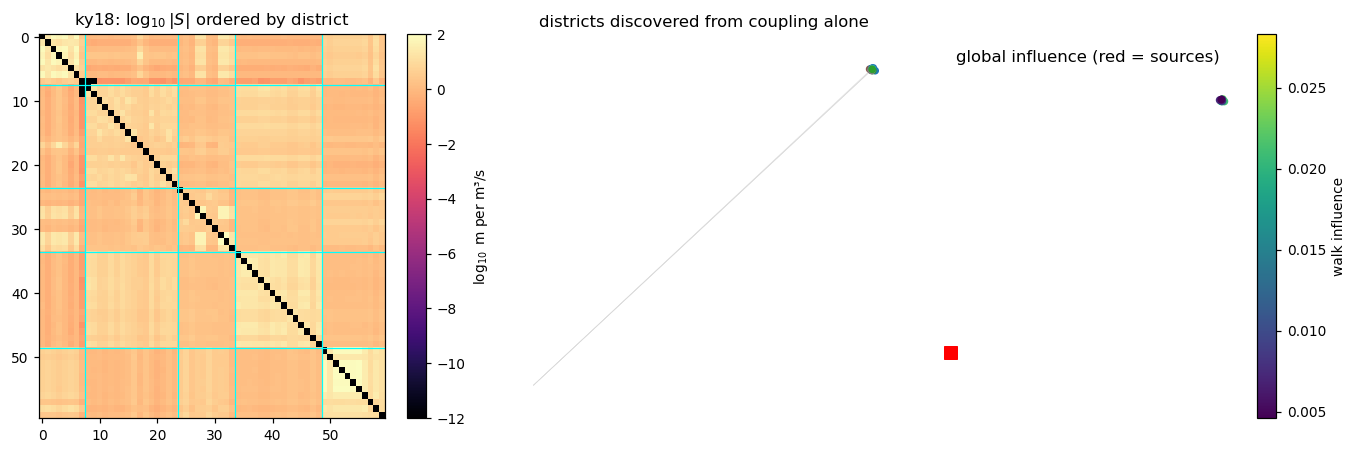

In [10]:
order = part.sort_values().index
A = np.log10(W.loc[order, order].to_numpy() + 1e-12)

fig = plt.figure(figsize=(12.5, 4.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1, 1])

a0 = fig.add_subplot(gs[0])
im = a0.imshow(A, cmap="magma", aspect="auto")
bounds = np.cumsum(part.sort_values().value_counts().sort_index().to_numpy())
for b in bounds[:-1]:
    a0.axhline(b - 0.5, color="cyan", lw=0.8)
    a0.axvline(b - 0.5, color="cyan", lw=0.8)
a0.set_title(f"{FOCUS}: $\\log_{{10}}|S|$ ordered by district")
plt.colorbar(im, ax=a0, label="$\\log_{10}$ m per m³/s")

a1 = fig.add_subplot(gs[1])
wn = d["wn"]
for lname in wn.pipe_name_list:
    l = wn.get_link(lname)
    c1 = wn.get_node(l.start_node_name).coordinates
    c2 = wn.get_node(l.end_node_name).coordinates
    if c1 and c2:
        a1.plot([c1[0], c2[0]], [c1[1], c2[1]], lw=0.3, color="0.85", zorder=1)
pts = np.array([wn.get_node(n).coordinates or (np.nan, np.nan) for n in part.index],
               dtype=float)
a1.scatter(pts[:, 0], pts[:, 1], c=part.to_numpy(), cmap="tab10", s=16, zorder=3)
a1.set_title("districts discovered from coupling alone")
a1.set_aspect("equal")
a1.axis("off")

a2 = fig.add_subplot(gs[2])
pts2 = np.array([wn.get_node(n).coordinates or (np.nan, np.nan) for n in rank.index],
                dtype=float)
sc = a2.scatter(pts2[:, 0], pts2[:, 1], c=rank.walk_influence.to_numpy(),
                cmap="viridis", s=18)
for n in wn.reservoir_name_list + wn.tank_name_list:
    c = wn.get_node(n).coordinates
    if c:
        a2.scatter(*c, marker="s", s=55, c="red", zorder=5)
plt.colorbar(sc, ax=a2, label="walk influence")
a2.set_title("global influence (red = sources)")
a2.set_aspect("equal")
a2.axis("off")
fig.tight_layout()
plt.show()

## 5. Operating-point stability

Influence is nonlinear in flow. If a map built at $\lambda = 0.5$ does not predict the map
at $\lambda = 2$, then any districting or sensor placement derived from a single operating
point is provisional — and since notebook 03 grows demand over the horizon, the operating
point *moves*. Spearman rank correlation is the quantity that matters: it asks whether the
*ordering* of couplings is preserved, which is what clustering and thresholding depend on.

In [11]:
stab = {}
for name in SELECTED.index:
    wn = wntr.network.WaterNetworkModel(str(NETWORK_DIR / f"{name}.inp"))
    try:
        r = dep.operating_point_stability(wn, CFG, probes=MAPS[name]["map"]["probes"])
        stab[name] = r["comparison"].assign(network=name)
    except Exception as exc:
        print(f"{name}: {type(exc).__name__}: {exc}")
stability = pd.concat(stab.values(), ignore_index=True) if stab else pd.DataFrame()
stability.to_csv(OUT_DIR / "operating_point_stability.csv", index=False)
display(stability.round(4))
print("Spearman near 1 means the coupling *ranking* is operating-point invariant, so a map "
      "built at one demand level remains usable as demand grows. A falling Spearman means "
      "the dependency map must be rebuilt along the growth trajectory.")

,lambda,pearson_vs_ref,spearman_vs_ref,scale_vs_ref,network
0,0.5,1.0000,1.0000,1.0000,Balerma
1,1.0,0.9981,0.9996,3.6123,Balerma
2,2.0,0.9969,0.9993,13.2531,Balerma
3,0.5,1.0000,1.0000,1.0000,ky17
4,1.0,0.9949,0.8934,1.8465,ky17
5,2.0,0.9902,0.7490,5.2578,ky17
6,0.5,1.0000,1.0000,1.0000,ky1
7,1.0,0.8540,0.9808,0.8537,ky1
8,2.0,0.9712,0.9893,5.1950,ky1
9,0.5,1.0000,1.0000,1.0000,ky16


Spearman near 1 means the coupling *ranking* is operating-point invariant, so a map built at one demand level remains usable as demand grows. A falling Spearman means the dependency map must be rebuilt along the growth trajectory.


## 6. Dynamic map: land-use shape perturbation and lag

The interventional probe that matches what land use actually does. Every consumer runs a
common diurnal shape; one node is switched to a different shape **normalised to the same
daily volume**. That normalisation is the control that makes this a shape experiment: without
it, swapping shapes also changes total volume and the map conflates "different rhythm" with
"more water".

The lag of peak cross-correlation is the physical propagation lag. **Prediction, stated
before running:** lag 0 everywhere on a network with no tanks and no controls, because
quasi-steady hydraulics has no state to carry information between timesteps; non-zero lag
only where storage or control switching exists. If this prediction fails, either the
implementation is wrong or there is a pathway we have not accounted for.

In [12]:
def diurnal_shapes(n_hours=24):
    """Two contrasting mean-1 shapes: a flat/industrial base and a peaky/residential probe.

    Generated from parameters rather than pasted arrays so the contrast is legible
    and adjustable. Both pass through `dep.normalized_shape`, which enforces the
    equal-volume control: any shape it returns has mean exactly 1, so swapping one
    for another changes rhythm without changing daily volume.
    """
    h = np.arange(n_hours) + 0.5
    flat = np.ones(n_hours)
    peaky = (0.35
             + 1.0 * np.exp(-0.5 * ((h - 7.5) / 2.2) ** 2)
             + 1.3 * np.exp(-0.5 * ((h - 19.5) / 2.2) ** 2))
    return dep.normalized_shape(flat), dep.normalized_shape(peaky)


SHAPE_BASE, SHAPE_PROBE = diurnal_shapes()
print('equal-volume control -> base mean %.6f, probe mean %.6f, probe peak factor %.3f'
      % (SHAPE_BASE.mean(), SHAPE_PROBE.mean(), SHAPE_PROBE.max()))

DYN_CFG = dep.DependencyConfig(**{**dep.asdict(CFG),
                                  'max_probe_nodes': 25,
                                  'dynamic_hours': 120,
                                  'dynamic_warmup_h': 48,
                                  'max_lag_h': 12})
DYN = {}
for name in SELECTED.index:
    wn = wntr.network.WaterNetworkModel(str(NETWORK_DIR / (name + '.inp')))
    try:
        DYN[name] = dep.dynamic_map(wn, SHAPE_BASE, SHAPE_PROBE, DYN_CFG, lam=1.0)
        r = DYN[name]
        lag = r['lag_h'].to_numpy()
        print('%-9s tanks=%2d controls=%3d lag_mechanism=%-5s median_lag=%4.1fh '
              'frac_lag_nonzero=%.3f max_response=%.4f m (%.0fs)'
              % (name, r['n_tanks'], r['n_controls'], str(r['has_lag_mechanism']),
                 np.nanmedian(lag), np.nanmean(lag > 0),
                 np.nanmax(r['magnitude'].to_numpy()), r['seconds']))
    except Exception as exc:
        print('%-9s FAILED %s: %s' % (name, type(exc).__name__, exc))


equal-volume control -> base mean 1.000000, probe mean 1.000000, probe peak factor 1.891
Balerma   tanks= 0 controls=  0 lag_mechanism=False median_lag= 0.0h frac_lag_nonzero=0.000 max_response=6.6795 m (6s)
ky17      tanks= 3 controls=  0 lag_mechanism=True  median_lag= 0.0h frac_lag_nonzero=0.258 max_response=0.1781 m (150s)
ky1       tanks= 2 controls=  0 lag_mechanism=True  median_lag= 0.0h frac_lag_nonzero=0.000 max_response=0.6482 m (24s)
ky16      tanks= 4 controls=  6 lag_mechanism=True  median_lag= 1.0h frac_lag_nonzero=0.793 max_response=1.3471 m (32s)
ky7       tanks= 3 controls=  2 lag_mechanism=True  median_lag= 3.0h frac_lag_nonzero=0.985 max_response=0.4623 m (9s)
ky18      tanks= 0 controls=  0 lag_mechanism=False median_lag= 0.0h frac_lag_nonzero=0.063 max_response=0.0993 m (32s)
ky4       tanks= 4 controls=  2 lag_mechanism=True  median_lag= 3.0h frac_lag_nonzero=0.995 max_response=0.1058 m (29s)
ky2       tanks= 3 controls=  2 lag_mechanism=True  median_lag= 9.0h fra

,n_tanks,n_controls,has_lag_mechanism,frac_lag_nonzero,median_lag_h,prediction_holds
network,,,,,,
Balerma,0,0,False,0.0000,0.0,"PASS (no lag, as predicted)"
ky17,3,0,True,0.2581,0.0,n/a (lag permitted)
ky1,2,0,True,0.0000,0.0,n/a (lag permitted)
ky16,4,6,True,0.7933,1.0,n/a (lag permitted)
ky7,3,2,True,0.9851,3.0,n/a (lag permitted)
ky18,0,0,False,0.0628,0.0,FAIL (lag without a mechanism)
ky4,4,2,True,0.9954,3.0,n/a (lag permitted)
ky2,3,2,True,0.9968,9.0,n/a (lag permitted)
ky14,3,3,True,0.0001,0.0,n/a (lag permitted)


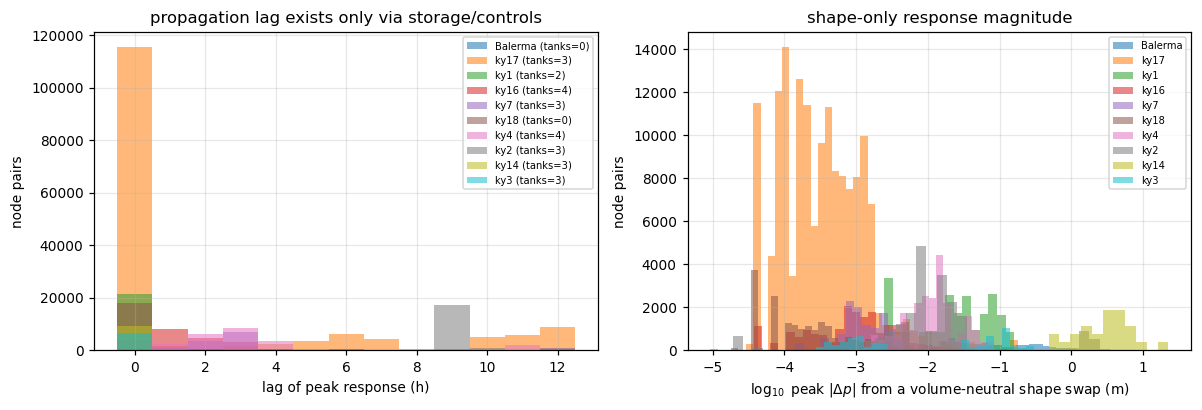

In [13]:
lag_test = pd.DataFrame([{
    "network": n,
    "n_tanks": r["n_tanks"], "n_controls": r["n_controls"],
    "has_lag_mechanism": r["has_lag_mechanism"],
    "frac_lag_nonzero": float(np.nanmean(r["lag_h"].to_numpy() > 0)),
    "median_lag_h": float(np.nanmedian(r["lag_h"].to_numpy())),
} for n, r in DYN.items()]).set_index("network")
lag_test["prediction_holds"] = np.where(
    lag_test.has_lag_mechanism,
    "n/a (lag permitted)",
    np.where(lag_test.frac_lag_nonzero < 0.05, "PASS (no lag, as predicted)",
             "FAIL (lag without a mechanism)"))
lag_test.to_csv(OUT_DIR / "lag_prediction_test.csv")
display(lag_test.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name, r in DYN.items():
    lag = r["lag_h"].to_numpy().flatten()
    lag = lag[np.isfinite(lag)]
    if lag.size:
        ax[0].hist(lag, bins=np.arange(-0.5, DYN_CFG.max_lag_h + 1.5), alpha=0.55,
                   label=f"{name} (tanks={r['n_tanks']})")
ax[0].set_xlabel("lag of peak response (h)")
ax[0].set_ylabel("node pairs")
ax[0].set_title("propagation lag exists only via storage/controls")
ax[0].legend(fontsize=6.5)

for name, r in DYN.items():
    mag = r["magnitude"].to_numpy().flatten()
    mag = mag[np.isfinite(mag) & (mag > 0)]
    if mag.size:
        ax[1].hist(np.log10(mag), bins=40, alpha=0.55, label=name)
ax[1].set_xlabel("$\\log_{10}$ peak |$\\Delta p$| from a volume-neutral shape swap (m)")
ax[1].set_ylabel("node pairs")
ax[1].set_title("shape-only response magnitude")
ax[1].legend(fontsize=6.5)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Persist the ground truth for notebook 03

Notebook 03 scores observational estimators against these matrices, so the node sets must
match exactly. The symmetrised instantaneous map is the coupling truth; the dynamic lag
matrix is the truth for *direction and timing*, which the symmetric instantaneous map cannot
provide.

In [14]:
ART = OUT_DIR / 'ground_truth'
ART.mkdir(parents=True, exist_ok=True)


def save_matrix(df, stem):
    """Persist a labelled matrix, preferring parquet but never requiring it.

    Notebook 03 reads these back, so the format has to be readable wherever the
    thesis code runs. Parquet keeps dtypes and is compact; CSV is universal. The
    chosen path is returned so the manifest records what actually happened rather
    than what was intended.
    """
    try:
        p = ART / (stem + '.parquet')
        df.to_parquet(p)
        return p
    except Exception:
        p = ART / (stem + '.csv')
        df.to_csv(p)
        return p


manifest = []
for name, d in MAPS.items():
    S = d['map']['S']
    paths = {'coupling': save_matrix(dep.symmetrize(S), name + '__coupling'),
             'S_raw': save_matrix(S, name + '__S_raw')}
    if name in DYN:
        paths['lag_h'] = save_matrix(DYN[name]['lag_h'], name + '__lag_h')
        paths['shape_response'] = save_matrix(DYN[name]['magnitude'],
                                              name + '__shape_response')
    manifest.append({
        'network': name,
        'n_probes': len(d['map']['probes']),
        'n_responders': d['map']['S'].shape[0],
        'delta_m3s': d['map']['delta_info'].get('delta_m3s', np.nan),
        'noise_floor_S_units': d['map']['noise_floor'],
        'quantisation_floor_m': d['map']['quantization_floor_m'],
        'rel_asymmetry': d['symmetry'].get('relative_asymmetry', np.nan),
        'format': paths['coupling'].suffix.lstrip('.'),
        'wntr': wntr.__version__,
        'seed': CFG.seed,
    })
pd.DataFrame(manifest).to_csv(ART / 'manifest.csv', index=False)
print('ground truth written to', ART)
pd.DataFrame(manifest).round(6)


ground truth written to data\08_reporting\dependency\ground_truth


,network,n_probes,n_responders,delta_m3s,noise_floor_S_units,quantisation_floor_m,rel_asymmetry,format,wntr,seed
0,Balerma,60,447,0.000050,0.326774,0.000016,0.000023,parquet,1.3.2,11
1,ky17,60,6261,0.000169,5.954374,0.000043,0.000675,parquet,1.3.2,11
2,ky1,60,859,0.000054,0.668800,0.000036,0.000014,parquet,1.3.2,11
3,ky16,60,798,0.000043,2.449497,0.000105,0.000404,parquet,1.3.2,11
4,ky7,60,485,0.000289,0.118625,0.000025,0.000107,parquet,1.3.2,11
5,ky18,60,776,0.000122,0.750500,0.000019,0.000344,parquet,1.3.2,11
6,ky4,60,964,0.000070,0.370484,0.000026,0.000330,parquet,1.3.2,11
7,ky2,60,815,0.000030,0.504691,0.000015,0.000724,parquet,1.3.2,11
8,ky14,60,384,0.000276,0.221240,0.000027,0.000121,parquet,1.3.2,11
9,ky3,60,275,0.000088,0.176274,0.000016,0.000882,parquet,1.3.2,11


## What we accomplished, and what remains unsafe

**Established.** An interventional dependence map whose correctness is tested rather than
assumed: reciprocity, sign, distance decay and zone structure all have pass/fail verdicts
above. A perturbation step chosen by measurement, against a precision limit we identified
(float32 output quantisation) rather than guessed at. A district partition derived from
hydraulic coupling alone and a *measured* inter-district coupling ratio, which turns "how
dependent are the federated clients?" into a number. And a falsifiable prediction about lag
that the dynamic map tests directly.

**Limitations to carry forward.**

1. **The instantaneous map is undirected**, by physics, not by choice. It can validate
   *whether* two nodes are coupled and cannot validate the *direction* of any causal edge.
   Direction has to be argued from the mechanisms that can carry it — storage, controls —
   and checked against the measured lag matrix.
2. **One operating point is not enough** if demand grows. Section 5 measures how far the
   ranking drifts; if Spearman falls materially, the map must be rebuilt along the
   trajectory rather than computed once.
3. **Probe subsetting** keeps large networks affordable, but a subset map cannot see
   coupling between unprobed pairs. It is a computational compromise, not a statistical one:
   the same node set must be used when scoring any estimator against it.
4. **Dense grids are weakly coupled in pressure.** Where the calibration curve bottoms out
   at the right edge, the required step approaches the node's own demand, and
   pressure-based dependence detection there is intrinsically hard. Flow is the better
   observable (`record_flow=True`), at the cost of a links × probes matrix.
5. **PRV-governed networks break reciprocity genuinely.** That is information, but it also
   means the symmetrised coupling matrix understates the true structure there, and such
   networks need the raw asymmetric $S$ rather than its symmetrisation.
6. **Tanks are held at their initial level** in the steady-state map. That is the correct
   instantaneous behaviour, but it is the *optimistic* end of the storage range; a map at
   minimum tank level would be more conservative and is worth building for any
   long-horizon claim.
7. **Leakage is absent.** Real systems lose 20–40% of production, pressure-dependently.
   Modelled as emitters it couples every node's demand to its own pressure and would change
   this structure materially. This is the largest single gap between these maps and a real
   distribution system.